In [18]:
# The ever-growning import block

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.optimize import differential_evolution
from scipy.spatial.distance import cdist

#from sklearn.preprocessing import StandardScaler
#from sklearn.linear_model import LogisticRegression
#from sklearn.model_selection import train_test_split
#from sklearn.metrics import confusion_matrix, accuracy_score
#from sklearn.model_selection import GridSearchCV
#from sklearn.metrics import accuracy_score

import sys

# Find the shared helpers from the notebook folder or either repository root.
stage = next(
    stage
    for root in (Path.cwd(), *Path.cwd().parents)
    for stage in (root / "stage-2-bbo", root / "Capstone/imperial-capstone/stage-2-bbo")
    if (stage / "src/initial_exploration.py").is_file()
)
if str(stage / "src") not in sys.path:
    sys.path.insert(0, str(stage / "src"))

from initial_exploration import (
    load_initial_data, preview, plot_ranked_locations, plot_sampling_gaps,
    maximin_candidates_2d, maximin_comparison, plot_maximin_choice,
    coverage_value_comparison, average_coverage_summary, plot_average_coverage,
    plot_ordered_outputs,
)

figures = stage.parent / ".runtime/function-1-side-work"



In [19]:
# Where's the data?
# Working snapshot relative to the Stage 2 workspace.
data_path = str(stage / "side-work" / "function_2")
data_filename = "observations.csv"
full_data_path = data_path + "\\" + data_filename

In [20]:
# Basic data load
print("Loading data from: " + full_data_path)
data = pd.read_csv(full_data_path)
# The exploration plots label observations by output rank (1 = highest).
data["rank"] = data["y"].rank(ascending=False, method="min").astype(int)

Loading data from: C:\_Source\Imperial-ML-AI-Live\Capstone\imperial-capstone\side-work\function_2\observations.csv


In [21]:
# Column inspection
columns = data.columns
print("Columns: ", columns)

Columns:  Index(['observation_id', 'source_round', 'x1', 'x2', 'y', 'rank'], dtype='str')


In [22]:
# Where we pray for good data, aka checking for nulls
print (data.isna().sum())

observation_id    0
source_round      0
x1                0
x2                0
y                 0
rank              0
dtype: int64


In [23]:
# Splitting our data into inputs X and outputs y
output_column = "y"
input_columns = ["x1", "x2"]

#print("Input columns: ", input_columns)
#print("Output column: ", output_column)

X = data[input_columns]
y = data[output_column]

#print("The inputs are given by :")
#print(X.head())
#print("The outputs are given by :")
#print(y[:5])


In [24]:
# Ok, here is where we go into more problem-specific territory. 
# We are approaching this as primarily a Bayesian optimization problem where we need to balance exploration and exploitation. 
# We will use a Gaussian Process to model the underlying function and then use an acquisition function to decide where to sample next.
# But first, let's visualize the data to get a better understanding of the underlying function.



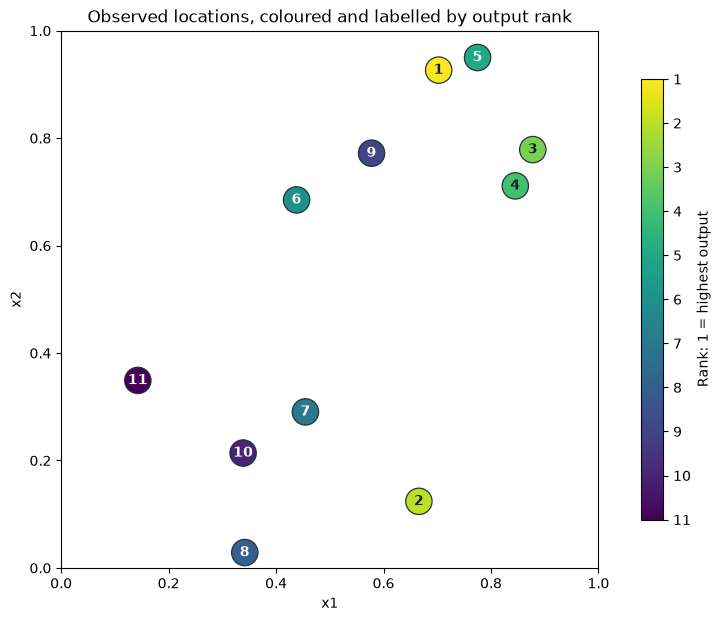

In [25]:
# Input space exploration visualisation
# We will use initial_exploration.py to generate some plots that will help us understand the input space and the distribution of the outputs.
# Moving on to analysis of input space coverage and output ranking. 
# This first plot shows the locations of the observations, ranked by their outputs. 
plot_ranked_locations(data, save_to=figures / "ranked-locations.png")

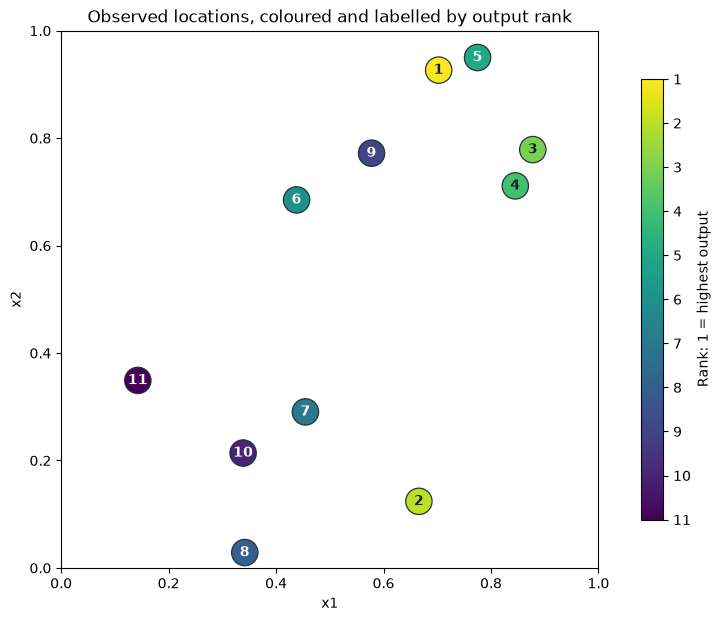

In [26]:
# Moving on to analysis of input space coverage and output ranking. 
# This first plot shows the locations of the observations, ranked by their outputs. 
plot_ranked_locations(data, save_to=figures / "ranked-locations.png")

In [27]:
# The most recent point is ranked 5. Seems to confirm that x1 > 0.7 is good, while adding uncertainty to the x2 dimension.
# Again, coverage seems to be a problem, with large gaps in the input space.
# plot_sampling_gaps(data, save_to=figures / "sampling-gaps.png")



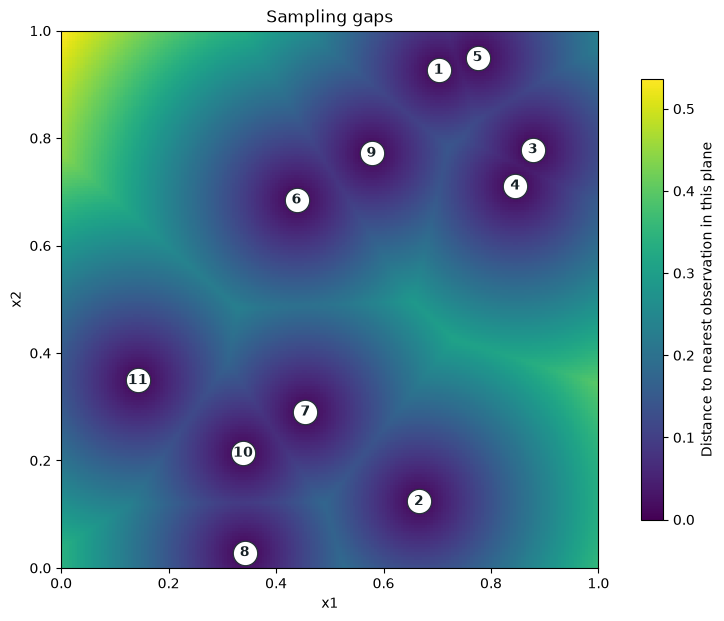

In [28]:
# This second plot shows the gaps in the input space that have not been sampled yet. 
# These plots will help us understand how well the input space has been explored and where we might want to sample next.
plot_sampling_gaps(data, save_to=figures / "sampling-gaps.png")

In [29]:
# There are still some gaps in the input space that have not been sampled yet.
# Gut feel says to use one query on the top left, then tactically explore poorly covered areas where x1 > 0.7.  
# 0.65,0.5 and 0.95,0.3 look like they could be good candidates for exploration.
# But the plan is to decide on a number of exploratory queries in advance, to even out information before beginning exploitation

In [30]:
# Helpers for maximin candidate selection and comparison, and for coverage value comparison.
MAX_VALUE = 0.999999

def make_2d_grid(n):
    axis = np.linspace(0.0, MAX_VALUE, n)
    x, y = np.meshgrid(axis, axis)

    return np.column_stack([
        x.ravel(),
        y.ravel()
    ])


def optimise_joint_minimax(existing, q, coverage_space, seed=42):
    n_dimensions = existing.shape[1]

    distance_to_existing = cdist(
        coverage_space,
        existing
    ).min(axis=1)

    def objective(flat_proposed):
        proposed = flat_proposed.reshape(q, n_dimensions)

        distance_to_proposed = cdist(
            coverage_space,
            proposed
        ).min(axis=1)

        nearest_distance = np.minimum(
            distance_to_existing,
            distance_to_proposed
        )

        return nearest_distance.max()

    result = differential_evolution(
        objective,
        bounds=[(0.0, MAX_VALUE)] * (q * n_dimensions),
        init="sobol",
        seed=seed,
        polish=True
    )

    return result.x.reshape(q, n_dimensions)

In [31]:
# Identifying the next best candidates.  
# Rather than assuming 'just one more' for the selection of further exploratory submissions, 
# I will commit to spend N additional candidates on exploration. 
# First, decide how many is most useful. Then, select the best candidates for that number.

optimization_space = make_2d_grid(51)
coverage_evaluation_space = make_2d_grid(201)
results = []

for q in range(13):
    if q == 0:
        proposed = np.empty((0, 2))
    else:
        proposed = optimise_joint_minimax(
            existing=X,
            q=q,
            coverage_space=optimization_space
        )

    design = np.vstack([X, proposed])

    distances = cdist(
        coverage_evaluation_space,
        design
    ).min(axis=1)

    results.append({
        "q": q,
        "max_distance": distances.max(),
        "p95_distance": np.percentile(distances, 95)
    })

In [32]:
coverage_results = pd.DataFrame(results)
coverage_results

,q,max_distance,p95_distance
0,0,0.539632,0.353982
1,1,0.397943,0.289425
2,2,0.342952,0.242847
3,3,0.289530,0.229993
4,4,0.286052,0.221271
5,5,0.243254,0.196522
6,6,0.231273,0.185895
7,7,0.230489,0.184455
8,8,0.204491,0.168894
9,9,0.187359,0.158633


In [33]:
coverage_results["relative_max_distance"] = (
    coverage_results["max_distance"]
    / coverage_results.loc[0, "max_distance"]
)

coverage_results["coverage_improvement"] = (
    1.0 - coverage_results["relative_max_distance"]
)

coverage_results["marginal_improvement"] = (
    coverage_results["max_distance"]
    .shift(1)
    - coverage_results["max_distance"]
)

coverage_results

,q,max_distance,p95_distance,relative_max_distance,coverage_improvement,marginal_improvement
0,0,0.539632,0.353982,1.000000,0.000000,NaN
1,1,0.397943,0.289425,0.737434,0.262566,0.141689
2,2,0.342952,0.242847,0.635530,0.364470,0.054990
3,3,0.289530,0.229993,0.536533,0.463467,0.053422
4,4,0.286052,0.221271,0.530087,0.469913,0.003478
5,5,0.243254,0.196522,0.450778,0.549222,0.042798
6,6,0.231273,0.185895,0.428575,0.571425,0.011981
7,7,0.230489,0.184455,0.427122,0.572878,0.000784
8,8,0.204491,0.168894,0.378945,0.621055,0.025998
9,9,0.187359,0.158633,0.347197,0.652803,0.017132


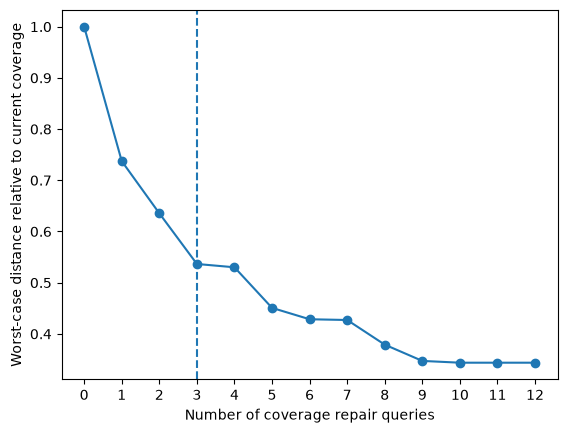

In [39]:

plt.plot(
    coverage_results["q"],
    coverage_results["relative_max_distance"],
    marker="o"
)

plt.axvline(3, linestyle="--")

plt.xlabel("Number of coverage repair queries")
plt.ylabel("Worst-case distance relative to current coverage")
plt.xticks(range(13))
plt.show()

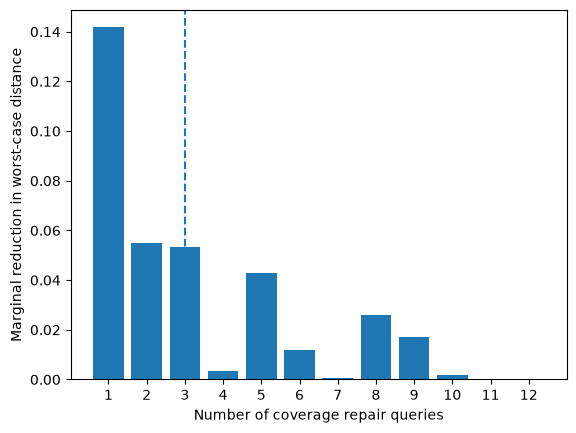

In [40]:
plt.bar(
    coverage_results["q"][1:],
    coverage_results["marginal_improvement"][1:]
)

plt.axvline(3, linestyle="--")

plt.xlabel("Number of coverage repair queries")
plt.ylabel("Marginal reduction in worst-case distance")
plt.xticks(range(1, 13))
plt.show()

In [36]:
coverage_results["max_distance"].diff()

0          NaN
1    -0.141689
2    -0.054990
3    -0.053422
4    -0.003478
5    -0.042798
6    -0.011981
7    -0.000784
8    -0.025998
9    -0.017132
10   -0.001875
11    0.000000
12    0.000000
Name: max_distance, dtype: float64

In [45]:
best_q3 = None

for seed in range(50):
    proposed = optimise_joint_minimax(
        existing=X,
        q=3,
        coverage_space=optimization_space,
        seed=seed
    )

    design = np.vstack([X, proposed])

    distances = cdist(
        coverage_evaluation_space,
        design
    ).min(axis=1)

    score = distances.max()

    if best_q3 is None or score < best_q3["score"]:
        best_q3 = {
            "score": score,
            "proposed": proposed,
            "seed": seed
        }

In [46]:
coverage_queries = pd.DataFrame(
    best_q3["proposed"],
    columns=["x1", "x2"]
)

coverage_queries

,x1,x2
0,0.064156,0.086067
1,0.863089,0.245889
2,0.200378,0.799116
